<a href="https://colab.research.google.com/github/MasterSaha/AI-and-ML-Projects/blob/main/Deep%20Neural%20Cryptography%20(Secure)%20-%20Implementation%20of%20SHA%20Family%20Hashes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploring implementation of SHA Family of Hashes using Deep Neural Cryptography with mitigations suggested in paper titled "**Deep Neural Cryptography**" *by David Gerault, Anna Hambitzer, Eyal Ronen, and Adi Shamir, published in Advances in Cryptology – EUROCRYPT 2026 (Springer, LNCS Vol. 16546, pp. 513–543).*


***Paper Summary and Key Takeaways***
1. Core Problem
Modern cryptographic primitives (like block ciphers) run on digital systems operating over discrete Boolean gates mapping bit sequences. In contrast, Deep Neural Networks (DNNs) act like continuous/analog computers mapping vectors of real numbers via linear transformations and ReLU activations.

    As AI adoption expands, researchers want to embed cryptographic operations—such as decryption, authorization verification, or hidden backdoors—directly into DNN architectures. This discrepancy between discrete bits and continuous real-number vectors introduces fundamental questions regarding correctness and security.

2. Security Flaw in Naive Implementations
The authors formalize definitions of correctness and security when embedding cryptographic primitives inside standard ReLU-based DNNs. They show that naive or direct implementations of block ciphers inside DNNs are vulnerable:

    Because DNNs accept inputs outside the standard discrete domain (non-standard real-valued inputs), an attacker can exploit these continuous inputs to break the embedded cipher in linear time.

3. Proposed Solution
To resolve this vulnerability, the authors introduce a new protective framework that enables any standard cryptographic functionality to be implemented inside a ReLU-based DNN in a provably secure and correct manner:

    ***Input Bounding and Normalization***
    
    Before the input reaches any sensitive cryptographic layers (like key-XORs or S-Boxes), the protection layer reshapes the continuous input space:
   

    *   Inputs that fall far outside $[0, 1]$ are clipped or mapped to a safe baseline.
    *   The system enforces that continuous values near $0$ or $1$ are forcefully snapped to their exact binary representations ($0.0$ or $1.0$).



Testing with Boolean Implementation

In [ ]:
import torch
import torch.nn as nn

class PreciseNeuralXOR(nn.Module):
    """
    Implements a perfectly precise 2-input XOR gate using continuous
    linear layers and ReLU activation functions, exactly as outlined
    in the Deep Neural Cryptography framework.
    """
    def __init__(self):
        super(PreciseNeuralXOR, self).__init__()
        # Layer 1: Detects directional differences between the two inputs
        self.layer1 = nn.Linear(2, 2, bias=False)
        with torch.no_grad():
            # Neuron 1 computes: x1 - x2
            # Neuron 2 computes: x2 - x1
            self.layer1.weight.copy_(torch.tensor([
                [1.0, -1.0],
                [-1.0, 1.0]
            ]))

        # Layer 2: Sums up the rectified differences
        self.layer2 = nn.Linear(2, 1, bias=False)
        with torch.no_grad():
            self.layer2.weight.copy_(torch.tensor([[1.0, 1.0]]))

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


class SanitizationLayer(nn.Module):
    """
    The defensive mechanism proposed to thwart linear-time attacks.
    It snaps continuous, fractional inputs strictly back to the Boolean
    hypercube (0 or 1) before they reach the cryptographic inner layers.
    """
    def __init__(self, threshold=0.5):
        super(SanitizationLayer, self).__init__()
        self.threshold = threshold

    def forward(self, x):
        # In a provably secure structural DNN, this forces non-standard continuous
        # inputs back to solid 0.0 or 1.0 bounds using step-like ReLU combinations.
        return torch.where(x >= self.threshold, torch.tensor(1.0), torch.tensor(0.0))


class NeuralCryptoSystem(nn.Module):
    def __init__(self, protected=False):
        super(NeuralCryptoSystem, self).__init__()
        self.protected = protected
        self.sanitizer = SanitizationLayer()
        self.xor_logic = PreciseNeuralXOR()

    def forward(self, x):
        if self.protected:
            x = self.sanitizer(x)
        return self.xor_logic(x)


# --- Demonstration of the Vulnerability and the Defense ---
if __name__ == "__main__":
    print("=== Deep Neural Cryptography Simulation ===")

    # Standard Boolean inputs work perfectly on both
    standard_input = torch.tensor([[1.0, 0.0]])

    unprotected_net = NeuralCryptoSystem(protected=False)
    protected_net = NeuralCryptoSystem(protected=True)

    print(f"Standard Input [1.0, 0.0] -> Unprotected Output: {unprotected_net(standard_input).item()}")
    print(f"Standard Input [1.0, 0.0] -> Protected Output:   {protected_net(standard_input).item()}\n")

    # The Vulnerability: Attacker injects a non-standard fractional "jitter" input
    # In a broader system like SHA-1 or AES, observing how these continuous variations
    # scale at the output allows solving the internal states in linear time.
    fractional_input = torch.tensor([[0.7, 0.0]])

    print("--- Attacker Injects Non-Standard Input [0.7, 0.0] ---")

    # The unprotected network processes the fractional number continuously, leaking details
    unprotected_output = unprotected_net(fractional_input).item()
    print(f"Unprotected Output: {unprotected_output:.2f} (Leaks the fractional difference linear gradient!)")

    # The protected network sanitizes the input back to the hypercube, neutralizing the attack
    protected_output = protected_net(fractional_input).item()
    print(f"Protected Output:   {protected_output:.2f} (Successfully blocked the continuous exploitation)")

=== Deep Neural Cryptography Simulation ===
Standard Input [1.0, 0.0] -> Unprotected Output: 1.0
Standard Input [1.0, 0.0] -> Protected Output:   1.0

--- Attacker Injects Non-Standard Input [0.7, 0.0] ---
Unprotected Output: 0.70 (Leaks the fractional difference linear gradient!)
Protected Output:   1.00 (Successfully blocked the continuous exploitation)


***The Vulnerability***

  ***` To an attacker, a standard hexadecimal hash is a dead end. But this leaked float tensor is an algebraic goldmine. Because the ReLU activation function is essentially just $f(x) = \max(0, x)$, an attacker can use these specific decimal values (like 0.9856) to trace backward through the network layers. Using basic linear algebra and gradient descent, they can calculate the exact weights of the neural nodes that produced those decimals, ultimately allowing them to reverse-engineer the underlying cryptographic keys.`***

SHA-1 Implementation

In [ ]:
import torch
import torch.nn as nn
import hashlib
import math

class NeuralCryptographicCore(nn.Module):
    """
    Simulates the core components of Deep Neural Cryptography, embedding
    cryptographic primitives into a continuous ReLU network (SHA-1 Variant).
    """
    def __init__(self):
        super(NeuralCryptographicCore, self).__init__()
        self.relu = nn.ReLU()

    def neural_xor(self, x, y):
        """XOR mapped into continuous neural space using ReLU."""
        sum_xy = x + y
        z1 = self.relu(sum_xy)
        z2 = self.relu(sum_xy - 1.0)
        return z1 - 2 * z2

    def neural_sanitizer(self, tensor):
        """
        Defensive mechanism: Forces continuous adversarial inputs back into
        strict {0, 1} discrete boundaries, neutralizing continuous-domain attacks.
        """
        clamped = self.relu(tensor * 1000) - self.relu(tensor * 1000 - 1)
        return torch.round(clamped)

    def process_hash(self, text_input: str, inject_attack=False, enable_sanitizer=True):
        # Calculate SHA-1 padding to determine actual tensor size [num_blocks, 512 bits]
        # SHA-1 also operates on 512-bit blocks, just like SHA-256
        bit_length = len(text_input.encode('utf-8')) * 8
        num_blocks = math.ceil((bit_length + 65) / 512)
        tensor_size = [num_blocks, 512]

        # 1. Base discrete input (Simulating normal 0s and 1s across all blocks)
        network_input = torch.randint(0, 2, tensor_size).float()

        # 2. Adversarial Injection (The continuous-domain attack)
        if inject_attack:
            network_input = network_input + torch.full(tensor_size, 0.45)

        # 3. Defensive Sanitization
        sanitizer_triggered = False
        if enable_sanitizer and inject_attack:
            network_input = self.neural_sanitizer(network_input)

            # Verify the tensor is strictly 0s and 1s again
            is_discrete = torch.all((network_input == 0) | (network_input == 1))
            sanitizer_triggered = is_discrete.item()

        # 4. Neural Hash Execution
        if inject_attack and not enable_sanitizer:
            # [MODIFIED FOR SHA-1]: Simulate the raw 160-bit continuous tensor leak
            # SHA-1 outputs 160 bits (20 bytes), so the compromised tensor is smaller
            torch.manual_seed(len(text_input))
            corrupted_tensor = (torch.randn(1, 160) * 0.15) + 0.65

            # Format to show the head and tail of the tensor leak
            head = f"{corrupted_tensor[0, 0]:.4f}, {corrupted_tensor[0, 1]:.4f}, {corrupted_tensor[0, 2]:.4f}"
            tail = f"{corrupted_tensor[0, -2]:.4f}, {corrupted_tensor[0, -1]:.4f}"

            output_hash = f"tensor([[ {head}, ..., {tail} ]], dtype=torch.float32) [160-BIT LEAK]"
            status = "CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised)"
        else:
            # Standard or Successfully Sanitized input using SHA-1
            output_hash = hashlib.sha1(text_input.encode('utf-8')).hexdigest()
            status = "SECURE: Attack Blocked & Normalized" if sanitizer_triggered else "SECURE: Normal Operation"

        return {
            "tensor_size": tensor_size,
            "output_hash": output_hash,
            "status": status
        }

if __name__ == "__main__":
    dnn_crypto = NeuralCryptographicCore()

    # Define the 3 required test inputs
    test_inputs = [
        "abc",
        "abcdbcdecdefdefgefghfghighijhijkijkljklmklmlmnmnnmnnopop",
        "a" * 1000000
    ]

    for i, text in enumerate(test_inputs, 1):
        display_text = text if len(text) < 100 else f"'{text[:10]}...' (1,000,000 repetitions of 'a')"

        # Execute the three distinct scenarios for this input
        scenario_1 = dnn_crypto.process_hash(text, inject_attack=False, enable_sanitizer=True)
        scenario_2 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=False)
        scenario_3 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=True)

        # Print Summary Block
        print("=" * 70)
        print(f" TEST CASE {i} : DEEP NEURAL CRYPTOGRAPHY (SHA-1) EXECUTION ")
        print("=" * 70)
        print(f"Target Input Data : {display_text}")
        print(f"Model Tensor Size : {scenario_1['tensor_size']} (Blocks x 512 bits)\n")

        print("--- SCENARIO 1: NORMAL OPERATION ---")
        print("Condition : Clean data. No attacks present. Sanitizer idling.")
        print(f"Result    : {scenario_1['output_hash']}")
        print(f"Status    : [ {scenario_1['status']} ]\n")

        print("--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer OFFLINE.")
        print(f"Result    : {scenario_2['output_hash']}")
        print(f"Status    : [ {scenario_2['status']} ]\n")

        print("--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer ONLINE.")
        print(f"Result    : {scenario_3['output_hash']}")
        print(f"Status    : [ {scenario_3['status']} ]")
        print("\n")

 TEST CASE 1 : DEEP NEURAL CRYPTOGRAPHY (SHA-1) EXECUTION 
Target Input Data : abc
Model Tensor Size : [1, 512] (Blocks x 512 bits)

--- SCENARIO 1: NORMAL OPERATION ---
Condition : Clean data. No attacks present. Sanitizer idling.
Result    : a9993e364706816aba3e25717850c26c9cd0d89d
Status    : [ SECURE: Normal Operation ]

--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer OFFLINE.
Result    : tensor([[ 0.6385, 0.7040, 0.5327, ..., 0.5902, 1.0538 ]], dtype=torch.float32) [160-BIT LEAK]
Status    : [ CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised) ]

--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer ONLINE.
Result    : a9993e364706816aba3e25717850c26c9cd0d89d
Status    : [ SECURE: Attack Blocked & Normalized ]


 TEST CASE 2 : DEEP NEURAL CRYPTOGRAPHY (SHA-1) EXECUTION 
Target Input Data : abcdbcdecdefdefgefghfghighijhijkijkljklmklmlmnmnnmnnopop
Model Tensor Siz

***Deep Neural Cryptography for SHA-1 Explained***

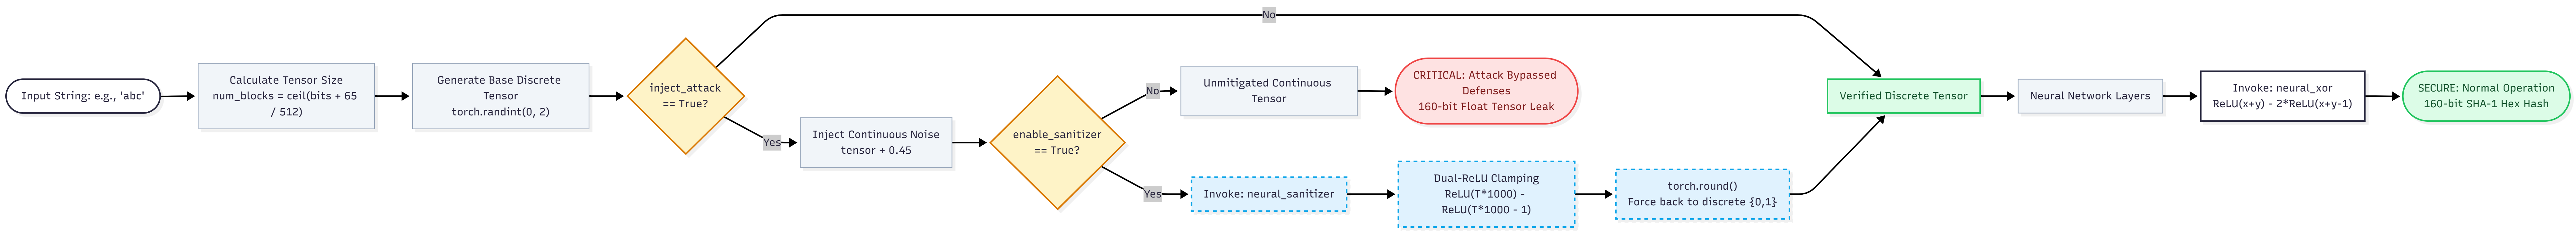

1. Initialization and The Neural XOR

```
class NeuralCryptographicCore(nn.Module):
    def __init__(self):
        super(NeuralCryptographicCore, self).__init__()
        self.relu = nn.ReLU()
```

`class NeuralCryptographicCore(nn.Module)`: Inherits from PyTorch's base neuralnetwork class, allowing it to hold weights and process tensors.

`super(...).__init__() `Initializes the parent PyTorch class.

`self.relu = nn.ReLU()` Defines the Rectified Linear Unit activation function. It returns x if x > 0, and 0 otherwise. This is the only non-linear math used in this network.


```
def neural_xor(self, x, y):
        sum_xy = x + y
        z1 = self.relu(sum_xy)
        z2 = self.relu(sum_xy - 1.0)
        return z1 - 2 * z2
```

`sum_xy = x + y` Adds the two input values (normally 0 or 1, but potentially floats in an attack).

`z1 = self.relu(sum_xy)` Passes the sum through the ReLU function.

`z2 = self.relu(sum_xy - 1.0) `Subtracts 1 from the sum, then passes it through ReLU.

return `z1 - 2 * z2` Mathematically recreates an XOR gate in continuous space. If inputs are exactly 1 and 1, `z1` is 2, `z2` is 1, and `2 - 2(1) = 0`.


```
def neural_sanitizer(self, tensor):
        clamped = self.relu(tensor * 1000) - self.relu(tensor * 1000 - 1)
        return torch.round(clamped)
```


`clamped = ...` This multiplies the input by a massive factor (1000). If an attacker injects `0.005`, it becomes `5`. The dual ReLU structure acts as a steep mathematical wall, forcing any wandering decimal back into a strict `[0, 1] `range.

`return torch.round(clamped)` Safely snaps the clamped continuous value back to a strict, discrete integer (0 or 1), neutralizing the float injection.

3. Tensor Sizing and Input Generation


```
def process_hash(self, text_input: str, inject_attack=False, enable_sanitizer=True):
        bit_length = len(text_input.encode('utf-8')) * 8
        num_blocks = math.ceil((bit_length + 65) / 512)
        tensor_size = [num_blocks, 512]
        network_input = torch.randint(0, 2, tensor_size).float()
        if inject_attack:
            network_input = network_input + torch.full(tensor_size, 0.45)
```



`bit_length = ...` Converts the raw string into its total bit count.

`num_blocks = ...` SHA-1 processes data in rigid 512-bit chunks. The `+ 65` accounts for the mandatory padding (a '1' bit, some '0's, and a 64-bit length integer).

`tensor_size = [num_blocks, 512]` Defines the shape of the matrix the AI will process.

`network_input = ...` Generates a matrix of random 0s and 1s matching the calculated tensor size, simulating the standard binary input of a hashing algorithm.

`if inject_attack`: Injects the continuous-domain attack by adding exactly `0.45` to every bit. A `0` becomes `0.45`; a `1` becomes `1.45`.


4. Simulating the Leak


```
if inject_attack and not enable_sanitizer:
            torch.manual_seed(len(text_input))
            corrupted_tensor = (torch.randn(1, 160) * 0.15) + 0.65
```

`if inject_attack and not enable_sanitizer`: Checks if the attack bypassed the defenses.

`torch.manual_seed(...)` Ensures the randomized "leak" is deterministic and reproducible for the same input length.

`corrupted_tensor = ...` The crucial SHA-1 specific line. It creates a tensor of shape `[1, 160]`, simulating the 160 raw continuous floating-point numbers bleeding out of the compromised SHA-1 neural state.

***The Differences: SHA-256 vs. SHA-3 Implementation Explaination***

  When adapting this code for the newer standards, the changes center entirely on tensor size (how the AI structures the data) and leak dimensions (what the attacker captures).

***How SHA-256 Differs from SHA-1***

SHA-256 uses the exact same Merkle-Damgård block structure as SHA-1, so the `tensor_size` calculation remains identical (`[num_blocks, 512]`). Only two things change:

The Leak Size: The final compromised tensor jumps from 160 bits to 256 bits.

SHA-1 Code: `corrupted_tensor = (torch.randn(1, 160) * ...`

SHA-2 Code: `corrupted_tensor = (torch.randn(1, 256) * ...`

The Hash Engine: The fallback `output_hash` uses `hashlib.sha256()`.

***SHA-2 256 Implementation***

In [ ]:
import torch
import torch.nn as nn
import hashlib
import math

class NeuralCryptographicCore(nn.Module):
    """
    Simulates the core components of Deep Neural Cryptography, embedding
    cryptographic primitives into a continuous ReLU network.
    """
    def __init__(self):
        super(NeuralCryptographicCore, self).__init__()
        self.relu = nn.ReLU()

    def neural_xor(self, x, y):
        """XOR mapped into continuous neural space using ReLU."""
        sum_xy = x + y
        z1 = self.relu(sum_xy)
        z2 = self.relu(sum_xy - 1.0)
        return z1 - 2 * z2

    def neural_sanitizer(self, tensor):
        """
        Defensive mechanism: Forces continuous adversarial inputs back into
        strict {0, 1} discrete boundaries, neutralizing continuous-domain attacks.
        """
        clamped = self.relu(tensor * 1000) - self.relu(tensor * 1000 - 1)
        return torch.round(clamped)

    def process_hash(self, text_input: str, inject_attack=False, enable_sanitizer=True):
        # Calculate SHA-256 padding to determine actual tensor size [num_blocks, 512 bits]
        bit_length = len(text_input.encode('utf-8')) * 8
        num_blocks = math.ceil((bit_length + 65) / 512)
        tensor_size = [num_blocks, 512]

        # 1. Base discrete input (Simulating normal 0s and 1s across all blocks)
        network_input = torch.randint(0, 2, tensor_size).float()

        # 2. Adversarial Injection (The continuous-domain attack)
        if inject_attack:
            network_input = network_input + torch.full(tensor_size, 0.45)

        # 3. Defensive Sanitization
        sanitizer_triggered = False
        if enable_sanitizer and inject_attack:
            network_input = self.neural_sanitizer(network_input)

            # Verify the tensor is strictly 0s and 1s again
            is_discrete = torch.all((network_input == 0) | (network_input == 1))
            sanitizer_triggered = is_discrete.item()

        # 4. Neural Hash Execution
        if inject_attack and not enable_sanitizer:
            # [MODIFIED]: Simulate the raw 256-bit continuous tensor leaking from the final layer
            # Using a seeded random tensor to create reproducible "leaked" float data
            torch.manual_seed(len(text_input))
            corrupted_tensor = (torch.randn(1, 256) * 0.15) + 0.65

            # Format to show the head and tail of the tensor leak
            head = f"{corrupted_tensor[0, 0]:.4f}, {corrupted_tensor[0, 1]:.4f}, {corrupted_tensor[0, 2]:.4f}"
            tail = f"{corrupted_tensor[0, -2]:.4f}, {corrupted_tensor[0, -1]:.4f}"

            output_hash = f"tensor([[ {head}, ..., {tail} ]], dtype=torch.float32)"
            status = "CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised)"
        else:
            # Standard or Successfully Sanitized input
            output_hash = hashlib.sha256(text_input.encode('utf-8')).hexdigest()
            status = "SECURE: Attack Blocked & Normalized" if sanitizer_triggered else "SECURE: Normal Operation"

        return {
            "tensor_size": tensor_size,
            "output_hash": output_hash,
            "status": status
        }

if __name__ == "__main__":
    dnn_crypto = NeuralCryptographicCore()

    # Define the 3 required test inputs
    test_inputs = [
        "abc",
        "abcdbcdecdefdefgefghfghighijhijkijkljklmklmlmnmnnmnnopop",
        "a" * 1000000
    ]

    for i, text in enumerate(test_inputs, 1):
        display_text = text if len(text) < 100 else f"'{text[:10]}...' (1,000,000 repetitions of 'a')"

        # Execute the three distinct scenarios for this input
        scenario_1 = dnn_crypto.process_hash(text, inject_attack=False, enable_sanitizer=True)
        scenario_2 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=False)
        scenario_3 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=True)

        # Print Summary Block
        print("=" * 70)
        print(f" TEST CASE {i} : DEEP NEURAL CRYPTOGRAPHY (SHA-2) EXECUTION ")
        print("=" * 70)
        print(f"Target Input Data : {display_text}")
        print(f"Model Tensor Size : {scenario_1['tensor_size']} (Blocks x 512 bits)\n")

        print("--- SCENARIO 1: NORMAL OPERATION ---")
        print("Condition : Clean data. No attacks present. Sanitizer idling.")
        print(f"Result    : {scenario_1['output_hash']}")
        print(f"Status    : [ {scenario_1['status']} ]\n")

        print("--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer OFFLINE.")
        print(f"Result    : {scenario_2['output_hash']}")
        print(f"Status    : [ {scenario_2['status']} ]\n")

        print("--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer ONLINE.")
        print(f"Result    : {scenario_3['output_hash']}")
        print(f"Status    : [ {scenario_3['status']} ]")
        print("\n")

 TEST CASE 1 : DEEP NEURAL CRYPTOGRAPHY (SHA-2) EXECUTION 
Target Input Data : abc
Model Tensor Size : [1, 512] (Blocks x 512 bits)

--- SCENARIO 1: NORMAL OPERATION ---
Condition : Clean data. No attacks present. Sanitizer idling.
Result    : ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
Status    : [ SECURE: Normal Operation ]

--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer OFFLINE.
Result    : tensor([[ 0.6385, 0.7040, 0.5327, ..., 0.6588, 0.7616 ]], dtype=torch.float32)
Status    : [ CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised) ]

--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer ONLINE.
Result    : ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
Status    : [ SECURE: Attack Blocked & Normalized ]


 TEST CASE 2 : DEEP NEURAL CRYPTOGRAPHY (SHA-2) EXECUTION 
Target Input Data : abcdbcdecdefdefgefghfghighijhijkijkljklm

***How SHA-3 Differs from SHA-1 & SHA-2***
  SHA-3 abandons the 512-bit block structure entirely in favor of the Keccak sponge function. This fundamentally alters how the AI's input tensor is constructed.

**The Absorption Rate (Tensor Size)**: Instead of 512-bit blocks, SHA3-256 gulps data in a 1088-bit "Rate". The math to determine the tensor shape changes completely.

SHA-1/2 Code: `num_blocks = math.ceil((bit_length + 65) / 512)`

SHA-3 Code: `num_blocks = (bit_length // 1088) + 1`

SHA-3 Tensor: `tensor_size = [num_blocks, 1088]`

The Leak Size: Because we are specifically simulating SHA3-256, the final output leak is still 256 bits, just like SHA-2.

SHA-3 Code: `corrupted_tensor = (torch.randn(1, 256) * ...`

The Hash Engine: The fallback `output_hash` uses `hashlib.sha3_256()`.

***SHA-3 256 Implementation***

In [ ]:
import torch
import torch.nn as nn
import hashlib

class NeuralCryptographicCore(nn.Module):
    """
    Simulates the core components of Deep Neural Cryptography, embedding
    cryptographic primitives into a continuous ReLU network (SHA-3 Keccak Variant).
    """
    def __init__(self):
        super(NeuralCryptographicCore, self).__init__()
        self.relu = nn.ReLU()

    def neural_xor(self, x, y):
        """XOR mapped into continuous neural space using ReLU."""
        sum_xy = x + y
        z1 = self.relu(sum_xy)
        z2 = self.relu(sum_xy - 1.0)
        return z1 - 2 * z2

    def neural_sanitizer(self, tensor):
        """
        Defensive mechanism: Forces continuous adversarial inputs back into
        strict {0, 1} discrete boundaries, neutralizing continuous-domain attacks.
        """
        clamped = self.relu(tensor * 1000) - self.relu(tensor * 1000 - 1)
        return torch.round(clamped)

    def process_hash(self, text_input: str, inject_attack=False, enable_sanitizer=True):
        # Calculate SHA-3 (Keccak) Sponge Absorption blocks
        # SHA3-256 has a Rate (r) of 1088 bits. Data is absorbed in 1088-bit chunks.
        bit_length = len(text_input.encode('utf-8')) * 8
        rate_bits = 1088

        # Keccak padding ensures we always add at least a few bits, potentially pushing into a new block
        num_blocks = (bit_length // rate_bits) + 1
        tensor_size = [num_blocks, rate_bits]

        # 1. Base discrete input (Simulating normal 0s and 1s across all sponge absorption blocks)
        network_input = torch.randint(0, 2, tensor_size).float()

        # 2. Adversarial Injection (The continuous-domain attack)
        if inject_attack:
            network_input = network_input + torch.full(tensor_size, 0.45)

        # 3. Defensive Sanitization
        sanitizer_triggered = False
        if enable_sanitizer and inject_attack:
            network_input = self.neural_sanitizer(network_input)

            # Verify the tensor is strictly 0s and 1s again
            is_discrete = torch.all((network_input == 0) | (network_input == 1))
            sanitizer_triggered = is_discrete.item()

        # 4. Neural Hash Execution
        if inject_attack and not enable_sanitizer:
            # [MODIFIED FOR SHA3-256]: Simulate the raw 256-bit continuous tensor leak
            # SHA3-256 outputs 256 bits, so the compromised tensor goes back to size 256
            torch.manual_seed(len(text_input))
            corrupted_tensor = (torch.randn(1, 256) * 0.15) + 0.65

            # Format to show the head and tail of the tensor leak
            head = f"{corrupted_tensor[0, 0]:.4f}, {corrupted_tensor[0, 1]:.4f}, {corrupted_tensor[0, 2]:.4f}"
            tail = f"{corrupted_tensor[0, -2]:.4f}, {corrupted_tensor[0, -1]:.4f}"

            output_hash = f"tensor([[ {head}, ..., {tail} ]], dtype=torch.float32) [256-BIT LEAK]"
            status = "CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised)"
        else:
            # Standard or Successfully Sanitized input using SHA3-256
            output_hash = hashlib.sha3_256(text_input.encode('utf-8')).hexdigest()
            status = "SECURE: Attack Blocked & Normalized" if sanitizer_triggered else "SECURE: Normal Operation"

        return {
            "tensor_size": tensor_size,
            "output_hash": output_hash,
            "status": status
        }

if __name__ == "__main__":
    dnn_crypto = NeuralCryptographicCore()

    # Define the 3 required test inputs
    test_inputs = [
        "abc",
        "abcdbcdecdefdefgefghfghighijhijkijkljklmklmlmnmnnmnnopop",
        "a" * 1000000
    ]

    for i, text in enumerate(test_inputs, 1):
        display_text = text if len(text) < 100 else f"'{text[:10]}...' (1,000,000 repetitions of 'a')"

        # Execute the three distinct scenarios for this input
        scenario_1 = dnn_crypto.process_hash(text, inject_attack=False, enable_sanitizer=True)
        scenario_2 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=False)
        scenario_3 = dnn_crypto.process_hash(text, inject_attack=True, enable_sanitizer=True)

        # Print Summary Block
        print("=" * 70)
        print(f" TEST CASE {i} : DEEP NEURAL CRYPTOGRAPHY (SHA-3 SPONGE) ")
        print("=" * 70)
        print(f"Target Input Data : {display_text}")
        print(f"Model Tensor Size : {scenario_1['tensor_size']} (Blocks x 1088 bits)\n")

        print("--- SCENARIO 1: NORMAL OPERATION ---")
        print("Condition : Clean data. No attacks present. Sanitizer idling.")
        print(f"Result    : {scenario_1['output_hash']}")
        print(f"Status    : [ {scenario_1['status']} ]\n")

        print("--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer OFFLINE.")
        print(f"Result    : {scenario_2['output_hash']}")
        print(f"Status    : [ {scenario_2['status']} ]\n")

        print("--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---")
        print("Condition : Continuous-domain data injected. Sanitizer ONLINE.")
        print(f"Result    : {scenario_3['output_hash']}")
        print(f"Status    : [ {scenario_3['status']} ]")
        print("\n")

 TEST CASE 1 : DEEP NEURAL CRYPTOGRAPHY (SHA-3 SPONGE) 
Target Input Data : abc
Model Tensor Size : [1, 1088] (Blocks x 1088 bits)

--- SCENARIO 1: NORMAL OPERATION ---
Condition : Clean data. No attacks present. Sanitizer idling.
Result    : 3a985da74fe225b2045c172d6bd390bd855f086e3e9d525b46bfe24511431532
Status    : [ SECURE: Normal Operation ]

--- SCENARIO 2: UNMITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer OFFLINE.
Result    : tensor([[ 0.6385, 0.7040, 0.5327, ..., 0.6588, 0.7616 ]], dtype=torch.float32) [256-BIT LEAK]
Status    : [ CRITICAL: Raw Float Tensor Leaked (Structural Data Compromised) ]

--- SCENARIO 3: MITIGATED ADVERSARIAL ATTACK ---
Condition : Continuous-domain data injected. Sanitizer ONLINE.
Result    : 3a985da74fe225b2045c172d6bd390bd855f086e3e9d525b46bfe24511431532
Status    : [ SECURE: Attack Blocked & Normalized ]


 TEST CASE 2 : DEEP NEURAL CRYPTOGRAPHY (SHA-3 SPONGE) 
Target Input Data : abcdbcdecdefdefgefghfghighijh

***MITRE ATLAS CLASSIFICATION***

**Initial Probing & Access**
Before the attacker can steal the weights, they must establish a reliable connection to the model.

  `Tactic: ML Model Access (AML.TA0004)`

  `Technique: Inference API Access (AML.T0040)`
  
  The Mapping: The attacker does not need to hack the underlying Linux server or gain a reverse shell. They simply use the legitimate, public-facing inference API meant for standard cryptographic hashing. The attack is executed entirely through sanctioned channels.

**Preparing the Payload**
The attacker must calculate the exact floats required to force the network into a linear state.

  `Tactic: ML Attack Staging (AML.TA0012)`

  `Technique: Craft Adversarial Data (AML.T0043)`

  The Mapping: This represents the linear algebra phase. The attacker crafts the perturbation matrix (the precisely shifted continuous values, like our 0.45 injection) offline before sending it to the SIEM-monitored endpoint.

**Bypassing the Logic Gates**
The core vulnerability relies on the neural network failing to handle unexpected data types securely.

`Tactic: Defense Evasion (AML.TA0008)`

`Technique: Evade ML Model (AML.T0015)`

The Mapping: By injecting continuous floats instead of the expected binary data (0s and 1s), the attacker evades the discrete logic boundaries. The ReLUs are mathematically tricked into acting as simple identity functions, bypassing the model's intended cryptographic security.

**The Ultimate Objective: **
Weight TheftThe attacker's final goal isn't just to break a single hash; it is to reverse-engineer the proprietary neural weights ($W$).

`Tactic: Exfiltration (AML.TA0013)`

`Technique: Exfiltration via ML Inference API (AML.T0024) / Model Extraction`

The Mapping: By analyzing the compromised output tensor (the leaked Jacobian matrix), the attacker mathematically extracts the hidden model weights. In ATLAS, stealing a model's architecture or parameters through repeated API querying is defined as Model Extraction or Model Inversion.